##Need to run milestone 3 first before running this



In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!pip install -q torch torchvision diffusers transformers accelerate pillow matplotlib ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.2 MB/s eta 0:00:00


In [5]:
import os
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

In [6]:
class DemoConfig:
    OUTPUT_DIR = "/content/drive/MyDrive/text2image_project"
    PROCESSED_DATA_DIR = os.path.join(OUTPUT_DIR, "processed_data")
    BASELINE_DIR = os.path.join(OUTPUT_DIR, "baseline_results")
    IMAGES_DIR = os.path.join(PROCESSED_DATA_DIR, "images")
    GENERATED_IMAGES_DIR = os.path.join(BASELINE_DIR, "generated_images")
    CFG_DIR = os.path.join(BASELINE_DIR, "cfg_experiments")
    SCHEDULER_DIR = os.path.join(BASELINE_DIR, "scheduler_experiments")

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    TEST_PROMPTS = [
        "a photo of a cat sitting on a window sill",
        "a beautiful sunset over the ocean with sailboats",
        "a robot playing chess in a futuristic city",
        "a bowl of fresh fruit on a wooden table",
        "an astronaut riding a horse on the moon"
    ]

config = DemoConfig()

print("Words to Worlds - Text-to-Image Generation Using Transformer and Diffusion Models - Group 3 Demo")
print(f"Device: {config.DEVICE}")
print(f"Project Directory: {config.OUTPUT_DIR}")


Words to Worlds - Text-to-Image Generation Using Transformer and Diffusion Models - Group 3 Demo
Device: cuda
Project Directory: /content/drive/MyDrive/text2image_project


In [7]:
try:
    with open(os.path.join(config.PROCESSED_DATA_DIR, "statistics.json")) as f:
        dataset_stats = json.load(f)
    print("Dataset statistics loaded")
except:
    dataset_stats = None
    print("Dataset statistics not found")

# Load evaluation report
try:
    with open(os.path.join(config.BASELINE_DIR, "evaluation_report.json")) as f:
        eval_report = json.load(f)
    print("Evaluation report loaded")
except:
    eval_report = None
    print("Evaluation report not found")

# Load generation results
try:
    with open(os.path.join(config.BASELINE_DIR, "generation_results.json")) as f:
        gen_results = json.load(f)
    print("Generation results loaded")
except:
    gen_results = None
    print("Generation results not found")



Dataset statistics loaded
Evaluation report loaded
Generation results loaded


In [8]:
def show_project_overview():
    print("PROJECT OVERVIEW")

    if dataset_stats:
        print(f"\n Dataset:")
        print(f"   • Total samples: {dataset_stats['total_samples']:,}")
        print(f"   • Image size: {dataset_stats['image_stats']['image_size']}")
        print(f"   • Mean caption length: {dataset_stats['caption_stats']['mean_word_count']:.1f} words")

    if eval_report:
        print(f"\n Evaluation Metrics:")
        if eval_report.get('fid'):
            print(f"   • FID Score: {eval_report['fid']:.2f}")
        if eval_report.get('inception_mean'):
            print(f"   • Inception Score: {eval_report['inception_mean']:.3f} ± {eval_report['inception_std']:.3f}")

        if eval_report.get('clip_alignment'):
            clip_scores = [x['clip_score'] for x in eval_report['clip_alignment']]
            print(f"   • Mean CLIP Score: {np.mean(clip_scores):.3f}")


In [9]:
def show_generated_gallery():
    """generated baseline images"""
    print("GENERATED IMAGES GALLERY")

    if not gen_results:
        print("No generation results found!")
        return

    n = len(gen_results)
    cols = min(3, n)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    elif cols == 1:
        axes = [[ax] for ax in axes]

    for idx, result in enumerate(gen_results):
        row, col = idx // cols, idx % cols
        ax = axes[row][col] if rows > 1 else axes[0][col]

        try:
            img = Image.open(result['image_path'])
            ax.imshow(img)
            ax.set_title(f"{result['prompt'][:40]}...", fontsize=9, wrap=True)
        except:
            ax.text(0.5, 0.5, "Image not found", ha='center', va='center')
        ax.axis('off')

    # Hide empty subplots
    for idx in range(n, rows * cols):
        row, col = idx // cols, idx % cols
        ax = axes[row][col] if rows > 1 else axes[0][col]
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [10]:
def show_cfg_comparison():
    """CFG scale comparison"""
    print("CFG SCALE COMPARISON")
    print("CFG (Classifier-Free Guidance) controls prompt adherence:")
    print("  • Low (3.0): More creative, less prompt-faithful")
    print("  • Medium (7.5): Balanced (default)")
    print("  • High (12.0): Strict prompt following, may oversaturate")

    cfg_values = [3.0, 7.5, 12.0]
    prompt = config.TEST_PROMPTS[0]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for idx, cfg in enumerate(cfg_values):
        filename = f"{prompt[:40].replace(' ', '_')}_cfg{cfg}.png"
        img_path = os.path.join(config.CFG_DIR, filename)

        try:
            img = Image.open(img_path)
            axes[idx].imshow(img)
            axes[idx].set_title(f"CFG = {cfg}", fontsize=12)
        except:
            axes[idx].text(0.5, 0.5, f"CFG={cfg}\nNot found", ha='center', va='center')
        axes[idx].axis('off')

    plt.suptitle(f'Prompt: "{prompt}"', fontsize=11)
    plt.tight_layout()
    plt.show()

    # Show CLIP scores if available
    if eval_report and eval_report.get('cfg_sensitivity'):
        df = pd.DataFrame(eval_report['cfg_sensitivity'])
        plt.figure(figsize=(10, 4))
        for p in config.TEST_PROMPTS:
            sub = df[df['prompt'] == p]
            if len(sub) > 0:
                plt.plot(sub['cfg'], sub['clip_score'], 'o-', label=p[:25]+'...')
        plt.xlabel('CFG Scale')
        plt.ylabel('CLIP Score')
        plt.title('CLIP Alignment vs CFG Scale')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

In [11]:
def show_scheduler_comparison():
    """noise scheduler comparison"""
    print("NOISE SCHEDULER COMPARISON")
    print("Different schedulers affect generation quality:")
    print("  • PNDM: Default SD1.5 scheduler")
    print("  • DDIM: Deterministic, smooth results")
    print("  • DPM-Solver: Often best quality/speed tradeoff")

    schedulers = ["default_pndm", "ddim", "dpm"]
    prompt = config.TEST_PROMPTS[0]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for idx, sched in enumerate(schedulers):
        filename = f"{prompt[:40].replace(' ', '_')}_{sched}.png"
        img_path = os.path.join(config.SCHEDULER_DIR, filename)

        try:
            img = Image.open(img_path)
            axes[idx].imshow(img)
            axes[idx].set_title(f"{sched.upper()}", fontsize=12)
        except:
            axes[idx].text(0.5, 0.5, f"{sched}\nNot found", ha='center', va='center')
        axes[idx].axis('off')

    plt.suptitle(f'Prompt: "{prompt}"', fontsize=11)
    plt.tight_layout()
    plt.show()

In [12]:
def show_clip_alignment():
    """CLIP alignment scores"""
    print("CLIP ALIGNMENT SCORES")
    print("CLIP score measures semantic similarity between prompt and image")
    print("  • 0.6-0.8: Strong alignment")
    print("  • 0.4-0.6: Moderate alignment")
    print("  • < 0.4: Weak alignment")

    if not eval_report or not eval_report.get('clip_alignment'):
        print("No CLIP alignment data found!")
        return

    df = pd.DataFrame(eval_report['clip_alignment'])

    plt.figure(figsize=(12, 5))
    bars = plt.barh(range(len(df)), df['clip_score'], color='steelblue')
    plt.yticks(range(len(df)), [p[:40]+'...' for p in df['prompt']], fontsize=9)
    plt.xlabel('CLIP Score')
    plt.title('Prompt-Image Alignment (CLIP Scores)')
    plt.xlim(0, 1)

    for bar, score in zip(bars, df['clip_score']):
        plt.text(score + 0.02, bar.get_y() + bar.get_height()/2,
                f'{score:.3f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

In [13]:
def interactive_demo():
    """interactive demo"""
    print("DEMO")

    output = widgets.Output()

    def on_button_click(b):
        with output:
            clear_output()
            if b.description == "Overview":
                show_project_overview()
            elif b.description == "Gallery":
                show_generated_gallery()
            elif b.description == "CFG Compare":
                show_cfg_comparison()
            elif b.description == "Schedulers":
                show_scheduler_comparison()
            elif b.description == "CLIP Scores":
                show_clip_alignment()

    buttons = []
    for name in ["Overview", "Gallery", "CFG Compare", "Schedulers", "CLIP Scores"]:
        btn = widgets.Button(description=name, button_style='info')
        btn.on_click(on_button_click)
        buttons.append(btn)

    display(widgets.HBox(buttons))
    display(output)

In [14]:
def load_pipeline_for_live_demo():
    """SD pipeline for live generation"""
    print("\nStable Diffusion pipeline")

    from diffusers import StableDiffusionPipeline

    pipe = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        torch_dtype=torch.float16 if config.DEVICE == "cuda" else torch.float32,
        safety_checker=None
    )
    pipe.enable_attention_slicing()
    pipe = pipe.to(config.DEVICE)

    print("Pipeline loaded!")
    return pipe

In [31]:
def live_generate(pipe, prompt, cfg=7.5, steps=30):
    print(f"\nGenerating: '{prompt}'")
    print(f"   CFG: {cfg}, Steps: {steps}")

    with torch.autocast(config.DEVICE):
        result = pipe(
            prompt,
            num_inference_steps=steps,
            guidance_scale=cfg,
            height=512,
            width=512
        )

    plt.figure(figsize=(8, 8))
    plt.imshow(result.images[0])
    plt.title(f'"{prompt}"\nCFG={cfg}, Steps={steps}')
    plt.axis('off')
    plt.show()

    return result.images


In [16]:
interactive_demo()

DEMO


Output()

#New Prompt

In [17]:
pipe = load_pipeline_for_live_demo()


Stable Diffusion pipeline


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Pipeline loaded!



Generating: 'a cup of coffee and a croissant on a cafe table'
   CFG: 7.5, Steps: 30


  0%|          | 0/30 [00:00<?, ?it/s]

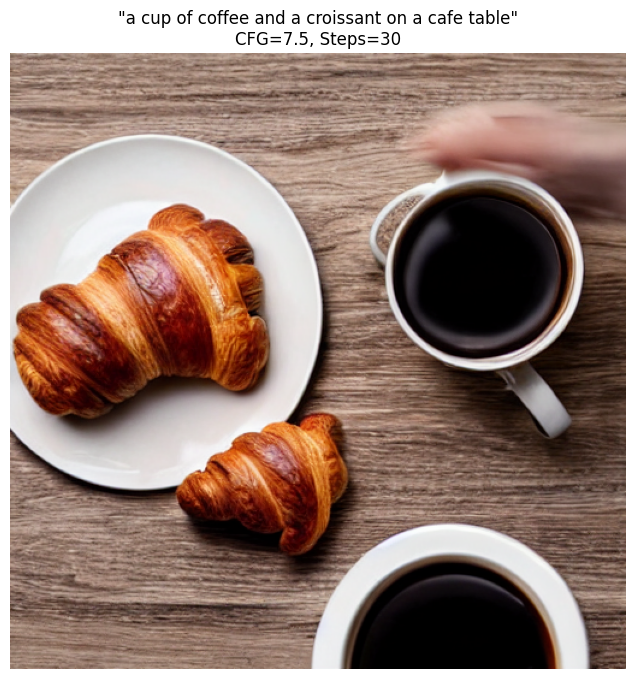

[<PIL.Image.Image image mode=RGB size=512x512>]

In [25]:
live_generate(pipe, 'a cup of coffee and a croissant on a cafe table')


Generating: 'a japanese garden with cherry blossoms and a wooden bridge'
   CFG: 7.5, Steps: 30


  0%|          | 0/30 [00:00<?, ?it/s]

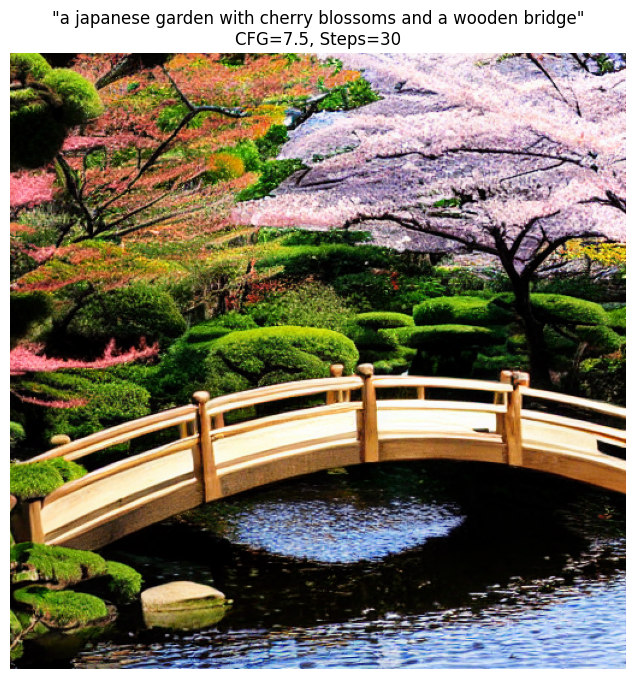

[<PIL.Image.Image image mode=RGB size=512x512>]

In [24]:
live_generate(pipe, 'a japanese garden with cherry blossoms and a wooden bridge')


Generating: 'a city made entirely of christmas decorations'
   CFG: 7.5, Steps: 30


  0%|          | 0/30 [00:00<?, ?it/s]

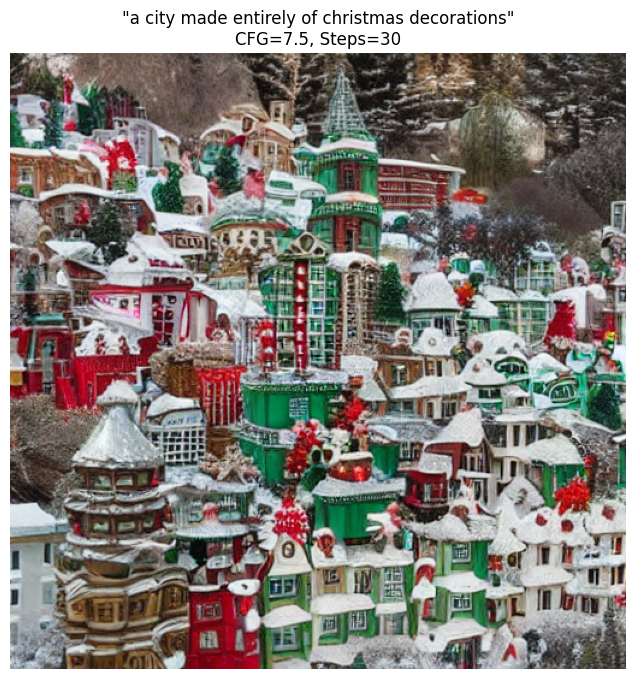

[<PIL.Image.Image image mode=RGB size=512x512>]

In [26]:
live_generate(pipe, 'a city made entirely of christmas decorations')


Generating: 'a blue cube on top of a red sphere next to a yellow pyramid with same heights'
   CFG: 7.5, Steps: 30


  0%|          | 0/30 [00:00<?, ?it/s]

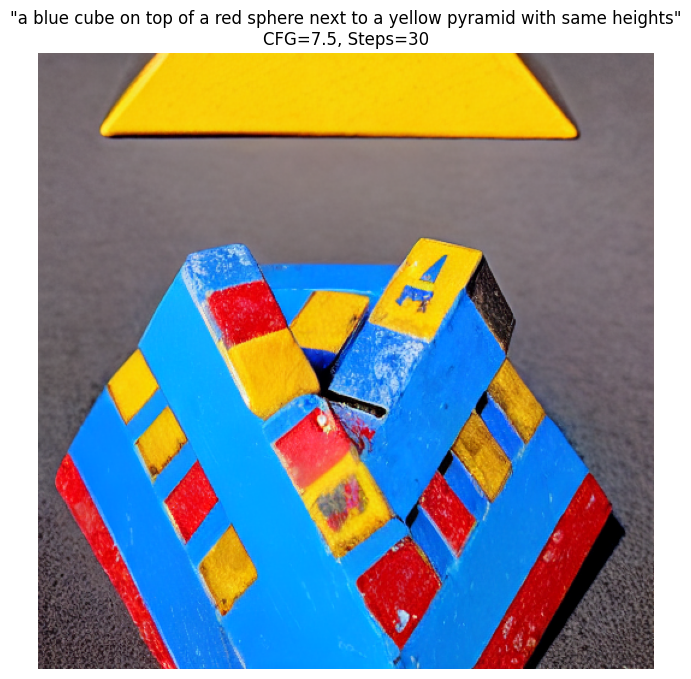

[<PIL.Image.Image image mode=RGB size=512x512>]

In [32]:
live_generate(pipe, 'a blue cube on top of a red sphere next to a yellow pyramid with same heights')